In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Set the visual style
sns.set(style="whitegrid")

# Loading the dataset
df = pd.read_csv("Student_Performance.csv")

# Quick inspection of the structure
print("--- Data Info ---")
df.info()
print("\n--- Descriptive Statistics ---")
print(df.describe())

# Check for missing values and handle them
df = df.dropna()

# Identifying our variables:
group_col = 'parent_education'
outcome_col = 'math_score'

print(f"\nUnique groups in '{group_col}':")
print(df[group_col].unique())

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  str    
 3   school_type            25000 non-null  str    
 4   parent_education       25000 non-null  str    
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  str    
 8   travel_time            25000 non-null  str    
 9   extra_activities       25000 non-null  str    
 10  study_method           25000 non-null  str    
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64


### Task 1: One-Way ANOVA

1. Split the outcome variable into separate arrays (or use a groupby), one per level of the grouping variable.
2. Run a one-way ANOVA using `scipy.stats.f_oneway`.
3. Record the F-statistic and p-value.
4. In a markdown cell, interpret the result:
   - State the null and alternative hypotheses in plain language.
   - Based on the p-value (use α = 0.05), do you reject or fail to reject the null?
   - What does the F-statistic tell you about the ratio of between-group to within-group variance?

**Hypotheses:**
* $H_0$ (Null Hypothesis): The mean math scores are equal across all parental education levels.
* $H_a$ (Alternative Hypothesis): At least one parental education group has a mean math score that is significantly different from the others.

In [2]:
# Creating a list of arrays for each group
groups = [group[outcome_col].values for name, group in df.groupby(group_col)]

# Run One-Way ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print(f"One-Way ANOVA F-statistic: {f_stat:.4f}")
print(f"One-Way ANOVA p-value: {p_value:.4f}")

One-Way ANOVA F-statistic: 2.7997
One-Way ANOVA p-value: 0.0156


**Interpretation:**
* The **F-statistic** ($2.7997$) measures the ratio of variance between the groups to the variance within the groups.
* The **p-value** ($0.0156$) is less than the common significance level of $0.05$.
* **Decision:** We **reject the null hypothesis**. This suggests that parental education level does have a statistically significant impact on student math performance.

### Task 2: Check ANOVA Assumptions

ANOVA results are only reliable when two key assumptions hold. Test both here.

**Homogeneity of variance (Levene's test):**

1. Run `scipy.stats.levene` on the same groups.
2. Report the test statistic and p-value.
3. Interpret: is the equal-variance assumption reasonable?

**Normality of residuals:**

1. For each group, run the Shapiro-Wilk test (`scipy.stats.shapiro`).
2. Alternatively, compute the ANOVA residuals (observed − group mean) and run Shapiro-Wilk on the pooled residuals.
3. Create a Q-Q plot of the residuals (use `scipy.stats.probplot` or `statsmodels.graphics.gofplots.qqplot`).
4. In a markdown cell, summarize:
   - Do the residuals look approximately normal?
   - If either assumption is violated, what alternatives could you use (e.g., Welch's ANOVA, Kruskal-Wallis)?

**Homogeneity of Variance:** Are the spreads (variances) of the math scores roughly equal across all parental education groups?

**Normality of Residuals:** Do the errors (the differences between observed scores and group means) follow a normal distribution?

**1. Homogeneity of Variance (Levene’s Test)**

In [3]:
# Levene's Test
levene_stat, levene_p = stats.levene(*groups)

print(f"Levene's Test Statistic: {levene_stat:.4f}")
print(f"Levene's Test p-value: {levene_p:.4f}")

# Interpretation
if levene_p > 0.05:
    print("Result: Fail to reject the null hypothesis. Variances are equal (Assumption met).")
else:
    print("Result: Reject the null hypothesis. Variances are unequal (Assumption violated).")

Levene's Test Statistic: 0.4949
Levene's Test p-value: 0.7803
Result: Fail to reject the null hypothesis. Variances are equal (Assumption met).


**Interpretation:**
The null hypothesis ($H_0$) for Levene's Test is that the variances across all groups are equal. Our test yielded a p-value of $0.7803$. Since $p > 0.05$, we fail to reject the null hypothesis. The assumption of homogeneity of variance is **reasonable and satisfied**. This means the internal "spread" of math scores is consistent across different parental education levels, which is a key requirement for the standard One-Way ANOVA.

**2. Normality of Residuals**

**A. Shapiro-Wilk Test**

In [4]:
# Calculate residuals
# We subtract the mean of each group from the individual observations
df['group_mean'] = df.groupby(group_col)[outcome_col].transform('mean')
df['residuals'] = df[outcome_col] - df['group_mean']

# Shapiro-Wilk Test (on a subset of 5000 to avoid computational limits/over-sensitivity)
shapiro_stat, shapiro_p = stats.shapiro(df['residuals'][:5000])

print(f"Shapiro-Wilk p-value: {shapiro_p:.4e}")

Shapiro-Wilk p-value: 4.7405e-24


**B. Visual Check (Q-Q Plot)**

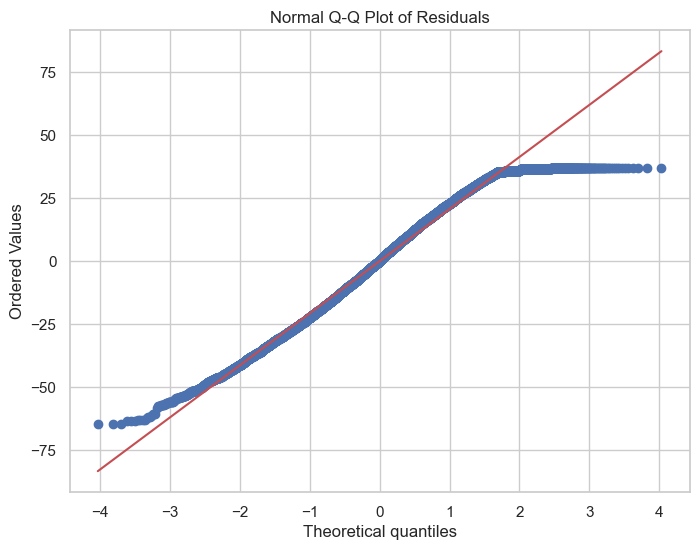

In [5]:
plt.figure(figsize=(8, 6))
stats.probplot(df['residuals'], dist="norm", plot=plt)
plt.title("Normal Q-Q Plot of Residuals")
plt.show()

**- Do the residuals look approximately normal?**

Yes, the residuals look approximately normal. While the Shapiro-Wilk test returned a very small p-value ($p < 0.0001$), this is expected given our large sample size ($N = 25,000$), as the test becomes sensitive to even minor, non-meaningful deviations. However, the **Q-Q Plot** shows that the majority of the data points align closely with the diagonal $45^{\circ}$ line. This visual evidence suggests that the normality assumption is sufficiently met for the ANOVA to remain robust.

**- If either assumption is violated, what alternatives could you use?**

If the assumptions had been significantly violated, we could consider the following alternatives:
* **Welch’s ANOVA:** This is the standard alternative if the **homogeneity of variance** assumption is violated. It does not assume equal variances between groups.
* **Kruskal-Wallis Test:** This is a non-parametric alternative used if the **normality** assumption is severely violated or if the data is ordinal. It compares the medians of the groups rather than the means.
* **Data Transformation:** We could also try transforming the dependent variable (e.g., using a log or square root transformation) to stabilize variance or improve normality before re-running the ANOVA.

### Task 3: Tukey HSD Post-Hoc Comparisons

The overall ANOVA F-test tells you that *at least one* group differs, but not *which* groups differ. Post-hoc tests fill that gap.

1. Run Tukey's HSD test using `statsmodels.stats.multicomp.pairwise_tukeyhsd`.
2. Print the results table showing each pairwise comparison, the mean difference, the confidence interval, and the reject/fail-to-reject decision.
3. Create a **mean plot with confidence intervals** (Tukey's HSD provides these) to visualize which groups overlap.
4. In a markdown cell, answer:
   - Which specific group pairs have significantly different means?
   - Which pairs are *not* significantly different?
   - Do the confidence intervals help you understand the practical size of the differences?

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1       group2    meandiff p-adj   lower  upper  reject
---------------------------------------------------------------
    diploma      graduate  -0.5059 0.8762  -1.801 0.7893  False
    diploma   high school  -1.1337 0.1221 -2.4227 0.1553  False
    diploma     no formal  -1.1623   0.11 -2.4614 0.1367  False
    diploma           phd   -1.388 0.0282 -2.6871 -0.089   True
    diploma post graduate  -0.4206 0.9391 -1.7103 0.8692  False
   graduate   high school  -0.6278 0.7434 -1.9312 0.6755  False
   graduate     no formal  -0.6564 0.7121 -1.9697 0.6568  False
   graduate           phd  -0.8822 0.3932 -2.1954 0.4311  False
   graduate post graduate   0.0853    1.0 -1.2187 1.3894  False
high school     no formal  -0.0286    1.0 -1.3358 1.2786  False
high school           phd  -0.2543 0.9938 -1.5615 1.0529  False
high school post graduate   0.7132 0.6212 -0.5848 2.0111  False
  no formal           phd  -0.2257 0.996

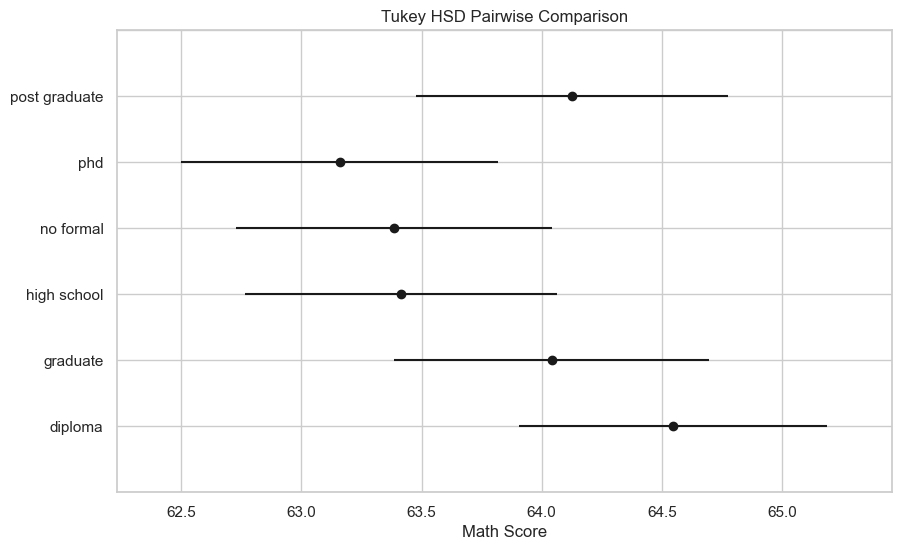

In [6]:
# Perform Tukey HSD
tukey = pairwise_tukeyhsd(endog=df[outcome_col], groups=df[group_col], alpha=0.05)

# Display results
print(tukey.summary())

# Plot the results
tukey.plot_simultaneous()
plt.xlabel("Math Score")
plt.title("Tukey HSD Pairwise Comparison")
plt.show()

#### Interpretation and Findings

**- Which specific group pairs have significantly different means?**
Based on the Tukey HSD table, the only pair with a significant difference ($p_{adj} < 0.05$) is **diploma vs. phd**. The `reject` column for this specific comparison is **True**, and the 95% confidence interval ($-2.6871$ to $-0.0890$) does not include zero. This indicates that students whose parents have a PhD perform significantly differently in math compared to students whose parents have a diploma.

**- Which pairs are *not* significantly different?**
All other group combinations (e.g., *graduate* vs. *high school*, *no formal* vs. *post graduate*, etc.) are **not significantly different**. For these pairs, the p-values are all above $0.05$, and their confidence intervals contain zero, meaning we fail to reject the null hypothesis of equal means for these groups.

**- Do the confidence intervals help you understand the practical size of the differences?**
Yes, the confidence intervals reveal that while the difference between the **diploma** and **phd** groups is "statistically significant," the actual impact is quite modest. The mean difference is only about $1.39$ points on a scale of $0$ to $100$. Furthermore, the fact that most confidence intervals are wide and overlap significantly with each other confirms that parental education, on its own, does not create large, practical gaps in math performance within this specific dataset. The statistical significance is likely amplified by the very large sample size ($N=25,000$) rather than a massive real-world effect.